# Séance 2 : Fouille de texte (Text Mining) avec Python
## Un corpus de presse historique sur les Jeux Olympiques

**Durée :** 1 journée (7h)
**Public :** Chercheurs et chercheuses en SHS ayant suivi la Séance 1 (bases de Python / pandas)
**Corpus :** `olympic_corpus.csv` — articles mentionnant les Jeux Olympiques, extraits de la collection ProQuest Chinese Newspapers via la plateforme **HistText**

---

## Déroulé de la journée (indicatif, à ajuster selon le rythme du groupe)

| Horaire | Durée | Bloc | Contenu |
|---|---|---|---|
| 9h00 – 9h15 | 15 min | 0. Introduction | Objectifs, présentation du corpus |
| 9h15 – 10h00 | 45 min | 1. Explorer le corpus | Métadonnées, nettoyage, statistiques descriptives |
| 10h00 – 10h45 | 45 min | 2. Concordances (KWIC) | Rechercher un mot dans son contexte |
| 10h45 – 11h00 | 15 min | ☕ Pause | |
| 11h00 – 12h00 | 60 min | 3. N-grammes & collocations | Bigrammes, trigrammes, expressions caractéristiques |
| 12h00 – 13h00 | 60 min | 🍽️ Déjeuner | |
| 13h00 – 14h15 | 75 min | 4. Topic Modeling (BERTopic) | Détecter les grands thèmes du corpus |
| 14h15 – 14h30 | 15 min | ☕ Pause | |
| 14h30 – 15h15 | 45 min | 5. Reconnaissance d'entités nommées (NER) | Personnes, lieux, organisations |
| 15h15 – 16h00 | 45 min | 6. Analyse de sentiment (bonus) | Tonalité des articles, si le temps le permet |
| 16h00 – 16h40 | 40 min | 7. Mini-projet de synthèse | Exercice récapitulatif en autonomie |
| 16h40 – 17h00 | 20 min | Aide-mémoire & clôture | Ressources, questions |

> 💡 **Comment utiliser ce notebook** : chaque section alterne explications, démonstrations et exercices **🧪 À vous de jouer**. Faites les exercices avant de regarder la solution, cachée dans un bloc repliable juste en dessous.

> ⚠️ **Installations nécessaires** (à faire en amont si possible, certaines bibliothèques sont volumineuses) :
> ```bash
> pip install pandas matplotlib seaborn plotly nltk scikit-learn spacy bertopic sentence-transformers
> python -m spacy download en_core_web_sm
> ```
> Sur **Google Colab**, ces bibliothèques sont pour la plupart préinstallées ; il suffit d'installer `bertopic` et le modèle spaCy.


# 0. Introduction

## Qu'est-ce que la fouille de texte ?

La **fouille de texte** (*text mining*) désigne l'ensemble des méthodes computationnelles permettant d'extraire de l'information, des structures ou des tendances à partir de grandes quantités de texte — trop volumineuses pour être lues intégralement "à la main". Pour un·e historien·ne ou un·e chercheur·se en SHS, il ne s'agit pas de remplacer la lecture attentive (*close reading*), mais de la compléter par une **lecture distante** (*distant reading*, selon l'expression de Franco Moretti) : repérer des patterns, orienter la lecture vers les passages ou documents les plus pertinents, et objectiver des impressions de lecture à l'échelle d'un corpus entier.

Aujourd'hui, nous allons appliquer six grandes familles de méthodes à un même corpus :

1. **Exploration du corpus et de ses métadonnées** — de quoi est composé le corpus ?
2. **Concordances (KWIC)** — comment un mot est-il utilisé, dans quel contexte ?
3. **N-grammes et collocations** — quelles expressions reviennent le plus souvent ?
4. **Topic modeling (BERTopic)** — quels grands thèmes structurent le corpus ?
5. **Reconnaissance d'entités nommées (NER)** — quelles personnes, quels lieux, quelles organisations sont mentionnés ?
6. **Analyse de sentiment** (si le temps le permet) — quelle tonalité se dégage des articles ?

## Le corpus

Le corpus que nous allons utiliser aujourd'hui a été constitué à partir de la collection [**ProQuest Chinese Newspapers**](https://stage-about.proquest.com/es/products-services/hnp_cnc/), une base de périodiques historiques anglophones publiés en Chine aux XIXe et XXe siècles. Il a été extrait à l'aide de [**HistText**](https://histtext.enpchina.eu/), une application dédiée à l'exploration de corpus historiques multilingues (recherche plein texte, filtrage par métadonnées, export de sous-corpus, extraction d'entités nommées, statistiques et visualisations).

Le fichier `olympic_corpus.csv` rassemble environ 17 000 articles mentionnant les Jeux Olympiques, publiés entre les années 1830 et 1953 (avec une forte concentration entre 1900 et 1953) dans des titres tels que le *South China Morning Post*, le *China Press*, le *Shanghai Times* ou le *North China Herald*.

### Les colonnes du corpus

| Colonne | Description |
|---|---|
| `DocId` | Identifiant unique du document |
| `Date` | Date de publication (format `AAAAMMJJ`) |
| `Title` | Titre de l'article |
| `Source` | Journal de publication |
| `Text` | Texte intégral de l'article (OCR) |
| `category` | Type de document (catégorie ProQuest détaillée) |
| `category_clean` | Type de document (catégorie simplifiée) |

<div class="alert alert-danger" role="alert" style="background-color:#f8d7da;padding:10px;border-radius:5px;">
⚠️ <b>À garder en tête toute la journée</b> : ce texte est issu d'une <b>reconnaissance optique de caractères (OCR)</b> appliquée à des microfilms/scans de journaux anciens. Il contient donc des erreurs de reconnaissance (mots tronqués, caractères mal reconnus, mise en page capturée comme du texte). Toutes nos analyses devront composer avec ce "bruit" — c'est une donnée constitutive du travail sur corpus historiques, pas un problème à "résoudre" complètement.
</div>


In [3]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

print("Bibliothèques chargées avec succès ✅")


Bibliothèques chargées avec succès ✅


# 1. Explorer le corpus et ses métadonnées

Comme pour tout projet de fouille de texte, la première étape consiste à **explorer et nettoyer les métadonnées** avant de plonger dans le texte lui-même. C'est une étape essentielle — et souvent sous-estimée — qui conditionne la qualité de toutes les analyses suivantes.

## Charger et inspecter le corpus


In [4]:
corpus = pd.read_csv("data/olympic_corpus.csv")
corpus.head(3)


,Unnamed: 0,DocId,Date,Title,Source,Text,category,category_clean
0,1,1756790435,19300911,OLYMPIC GAMES,South China Morning Post Ltd.,OLYMPIC GAMES Definite Dates f...,"Article, Feature",Feature/Article
1,2,1765635914,19510906,OLYMPIC GAMES,South China Morning Post Ltd.,OLYMPIC GAMES Russia's Entry M...,"Article, Feature",Feature/Article
2,3,1759724338,19360731,OLYMPIC COMMITTEE,South China Morning Post Ltd.,OLYMPIC COMMITTEE Philippines ...,"Article, Feature",Feature/Article


In [5]:
corpus.shape


(16966, 8)

In [6]:
corpus.columns


Index(['Unnamed: 0', 'DocId', 'Date', 'Title', 'Source', 'Text', 'category', 'category_clean'], dtype='object')

In [7]:
corpus.dtypes


Unnamed: 0         int64
DocId              int64
Date               int64
Title             object
Source            object
Text              object
category          object
category_clean    object
dtype: object

On remarque une colonne `Unnamed: 0` qui n'est qu'un ancien index recopié lors d'un export — on peut la supprimer. On remarque aussi que `Date` est de type numérique (`int64`), au format `AAAAMMJJ` (par exemple `19300911` pour le 11 septembre 1930) : il faut la convertir en véritable **date**.


In [8]:
corpus = corpus.drop(columns=["Unnamed: 0"])

corpus["Date"] = pd.to_datetime(corpus["Date"], format="%Y%m%d", errors="coerce") # convertir la colonne "Date" en type datetime
corpus["Year"] = corpus["Date"].dt.year                                           # create a new column for the year
corpus["Decade"] = (corpus["Year"] // 10) * 10                                    # créer une nouvelle colonne pour la décennie

corpus[["DocId", "Date", "Year", "Decade", "Title", "Source"]].head()


,DocId,Date,Year,Decade,Title,Source
0,1756790435,1930-09-11,1930,1930,OLYMPIC GAMES,South China Morning Post Ltd.
1,1765635914,1951-09-06,1951,1950,OLYMPIC GAMES,South China Morning Post Ltd.
2,1759724338,1936-07-31,1936,1930,OLYMPIC COMMITTEE,South China Morning Post Ltd.
3,1499037468,1913-09-03,1913,1910,OLYMPIC GAMES,South China Morning Post Ltd.
4,1766524422,1949-04-23,1949,1940,OLYMPIC GAMES,South China Morning Post Ltd.


<div class="alert alert-success" role="alert" style="background-color:#d4edda;padding:10px;border-radius:5px;">

**💡 Explications :**
 
* <code>errors="coerce"</code> transforme en <code>NaT</code> (Not a Time, l'équivalent d'un NA pour les dates) toute valeur qui ne peut pas être convertie, plutôt que de faire planter le script — un réflexe utile face à des métadonnées imparfaites.
* L’accesseur <code>.dt</code> permet de manipuler une colonne de dates et d’accéder à ses différentes composantes : année, mois, jour, etc.
* L'opérateur <code>//</code> correspond à une division entière : il divise et ne conserve que la partie entière du résultat. On multiplie ensuite par 10 (*10) pour arrondir à la décennie.   
</div>

## Nettoyer le texte

Le texte extrait par OCR contient souvent de longues suites d'espaces (dues à la mise en page en colonnes). On les normalise avec une expression régulière :

In [9]:
def clean_text(text):
    if pd.isna(text):
        return ""
    return re.sub(r"\s+", " ", text).strip()

corpus["Text_clean"] = corpus["Text"].apply(clean_text)

# Comparons avant / après sur le premier article
print(corpus["Text"].iloc[0][:200])
print("---")
print(corpus["Text_clean"].iloc[0][:200])


OLYMPIC GAMES                 Definite Dates for Los Angeles Event                 SIXTEEN DAYS                 Los Angeles Calif                 Definite dates for the celebration of the World Olympi
---
OLYMPIC GAMES Definite Dates for Los Angeles Event SIXTEEN DAYS Los Angeles Calif Definite dates for the celebration of the World Olympic Games in this city in 1932, will be from Saturday July 30, to 


<div class="alert alert-success" role="alert" style="background-color:#d4edda;padding:10px;border-radius:5px;">

💡 **Définition d'une fonction (def)**

Une **fonction** est un bloc de code réutilisable qui réalise une tâche précise. Elle peut recevoir une **entrée**, la traiter, puis `return` renvoie un **résultat**. Une fonction est définie avec `def` : on écrit ainsi une opération une seule fois pour pouvoir la réutiliser.

```python
def clean_text(text):
    if pd.isna(text):
        return ""
    return re.sub(r"\s+", " ", text).strip()
```

Ici :

* `clean_text` est le **nom de la fonction** ;
* `text` est la **valeur donnée en entrée** ;
* `if` définit une condition. Ici, si la valeur est manquante (NaN), la fonction la remplace par une chaîne de caractères vide `""` ;
* `return` renvoie le **résultat**. Ici, <code>re.sub(r"\s+", " ", text)</code> remplace toute séquence d'espaces, tabulations ou sauts de ligne par un seul espace. C'est une opération de nettoyage extrêmement fréquente en fouille de texte, à conserver dans votre boîte à outils.
* `.strip()` supprime les espaces inutiles au début et à la fin du texte ;
* `.apply(clean_text)` applique ensuite cette fonction à **chaque valeur d'une colonne pandas**.

```python
corpus["Text_clean"] = corpus["Text"].apply(clean_text)
```

En résumé : **on définit une recette une fois → on l'applique ensuite à de nombreuses valeurs.**
</div>
 


## Repérer les valeurs manquantes

Comme dans tout dataframe, on vérifie la présence de valeurs manquantes :

In [10]:
corpus.isna().sum()


DocId             0
Date              0
Title             0
Source            0
Text              0
category          0
category_clean    0
Year              0
Decade            0
Text_clean        0
dtype: int64

## Explorer les métadonnées

Combien d'articles par journal (`Source`) ?

In [11]:
corpus["Source"].value_counts()


Source
South China Morning Post Ltd.    7885
The China Press                  4978
The Shanghai Times               2130
The North China Herald           1317
The Shanghai Gazette              299
The China Weekly Review           236
The Canton Times                   41
Peking Daily News                  28
The Chinese Recorder               28
Peking Gazette                     20
The Peking Leader                   3
The Chinese Repository              1
Name: count, dtype: int64

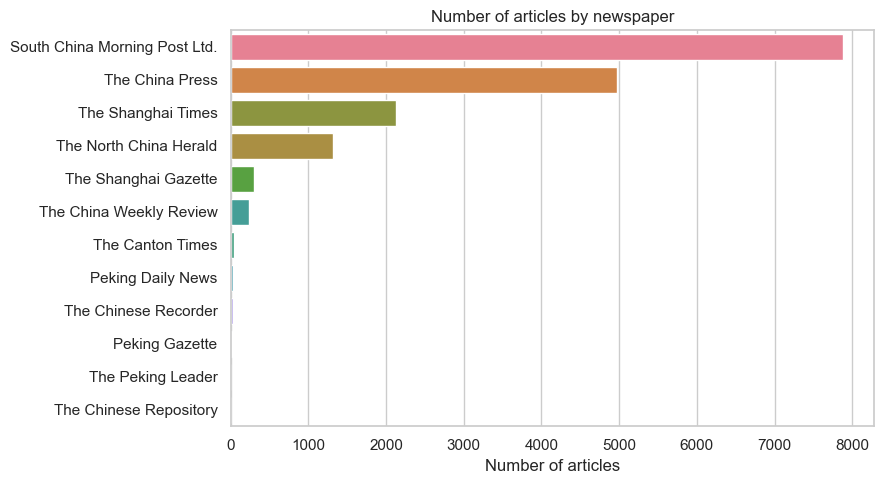

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
order = corpus["Source"].value_counts().index
sns.countplot(data=corpus, y="Source", order=order, hue="Source", legend=False, ax=ax)
ax.set_title("Number of articles by newspaper")
ax.set_xlabel("Number of articles")
ax.set_ylabel(None)
plt.tight_layout()
plt.show()


Et par type de document (`category_clean`) ?

In [13]:
corpus["category_clean"].value_counts()


category_clean
Feature/Article      12111
Advertisement         3401
General News           746
Visual/Graphic         321
Editorial/Opinion      261
Other                   64
Review                  37
Market                  17
Announcement             8
Name: count, dtype: int64

On observe une proportion importante de **publicités** (`Advertisement`), qui mentionnent souvent les Jeux Olympiques de façon incidente (ex. un cinéma "Olympic Theatre", une marque de cigarettes...). Pour la suite de nos analyses textuelles, on choisira souvent de se concentrer sur les articles rédactionnels (`Feature/Article`, `General News`, `Editorial/Opinion`) plutôt que sur l'ensemble du corpus.

In [14]:
editorial_types = ["Feature/Article", "General News", "Editorial/Opinion", "Review"]
articles = corpus[corpus["category_clean"].isin(editorial_types)].copy()

print(f"Corpus complet : {len(corpus)} documents")
print(f"Sous-corpus rédactionnel : {len(articles)} documents")


Corpus complet : 16966 documents
Sous-corpus rédactionnel : 13155 documents


## Distribution temporelle

Combien d'articles par année ?

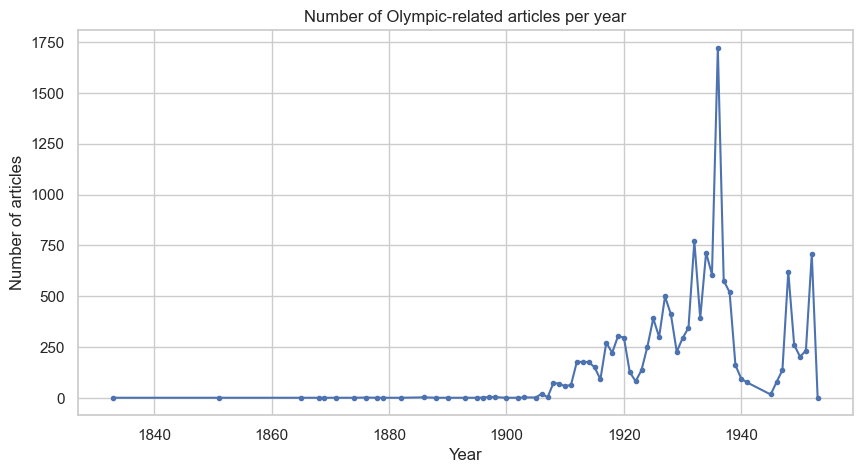

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
articles["Year"].value_counts().sort_index().plot(kind="line", marker="o", markersize=3, ax=ax)

ax.set_title("Number of Olympic-related articles per year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of articles")
plt.show()


On observe des **pics** qui correspondent vraisemblablement aux années où se tenaient les Jeux Olympiques (été et hiver). C'est un bon réflexe en histoire : confronter un pic statistique à sa connaissance du contexte historique — ici, le calendrier olympique (1932 Los Angeles, 1936 Berlin, 1948 Londres, 1952 Helsinki...).

## Longueur des documents

La longueur des articles (en nombre de mots) est une information utile, en particulier pour anticiper les temps de calcul des méthodes que nous verrons plus tard (BERTopic, NER) :

In [16]:
articles["n_words"] = articles["Text_clean"].str.split().str.len()

articles["n_words"].describe()


count    13155.000000
mean       512.577955
std        629.798420
min          1.000000
25%        143.000000
50%        319.000000
75%        678.000000
max      11693.000000
Name: n_words, dtype: float64

<div class="alert alert-success" role="alert" style="background-color:#d4edda;padding:10px;border-radius:5px;">

**💡 Explications :**

* <code>articles["Text_clean"]</code> sélectionne la colonne contenant les textes nettoyés ;
* <code>.str</code> permet d'appliquer des opérations sur des chaînes de caractères dans une colonne pandas ;
* <code>.split()</code> découpe chaque texte en une liste de mots, en utilisant les espaces comme séparateurs (opération aussi appelée *tokenization*) ;
* <code>.str.len()</code> compte le nombre d'éléments dans chaque liste, donc le nombre de mots ;
* <code>articles["n_words"] =</code> enregistre ce résultat dans une nouvelle colonne appelée "n_words".
* <code>.describe()</code> fournit un résumé statistique de la variable "n_words".

</div>

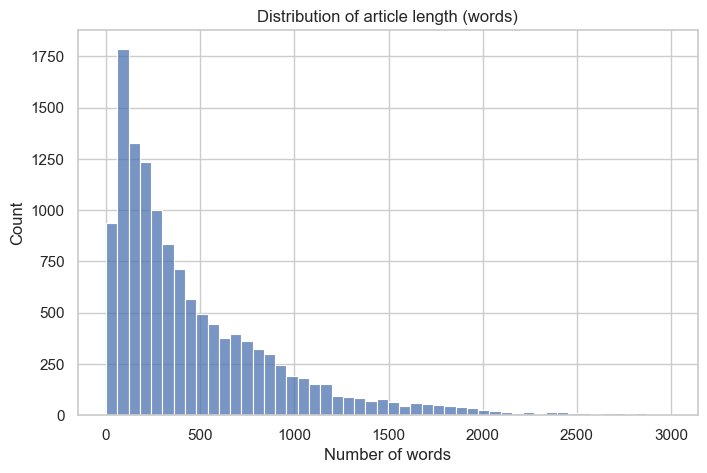

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=articles[articles["n_words"] < 3000], x="n_words", bins=50, ax=ax)
ax.set_title("Distribution of article length (words)")
ax.set_xlabel("Number of words")
plt.show()


## 🧪 À vous de jouer — Exercice 1

En utilisant `articles` (le sous-corpus rédactionnel) :

1. Combien d'articles ont été publiés en 1936 (l'année des Jeux de Berlin) ?
2. Quel est le journal qui a publié le plus d'articles sur les JO pendant les années 1930 (`Decade == 1930`) ?
3. Quel est le titre de l'article le plus long du corpus (en nombre de mots) ? Affichez ses 300 premiers caractères.
4. Réalisez un barplot du nombre d'articles par décennie.
5. Créez un sous-corpus ne contenant que les journaux ayant plus de 100 articles sur les Jeux Olympiques. 
6. Eliminez du corpus les articles qui comportent moins de 10 mots (éviter d'écraser le corpus d'origine). 


In [ ]:
# 🧪 Essayez ici




<details>
<summary>▶️ Voir la solution</summary>

```python
# Question 1
articles[articles["Year"] == 1936].shape[0]

# Question 2
articles[articles["Decade"] == 1930]["Source"].value_counts().head(1)

# Question 3
longest = articles.loc[articles["n_words"].idxmax()]
print(longest["Title"])
print(longest["Text_clean"][:300])

# Question 4
counts_decade = articles["Decade"].value_counts().sort_index().reset_index()
counts_decade.columns = ["Decade", "n"]

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=counts_decade, x="Decade", y="n", hue="Decade", legend=False, ax=ax)
ax.set_title("Number of articles by decade")
plt.show()

# Question 5

source_counts = corpus["Source"].value_counts() # Compter le nombre d'articles par journal
journaux_100 = source_counts[source_counts > 100] # Sélectionner les journaux ayant plus de 100 articles
corpus_100 = corpus[corpus["Source"].isin(journaux_100.index)] # Filtrer ces titres dans le corpus principal

# alternative (plus rapide)
corpus_100 = corpus[corpus.groupby("Source")["Source"].transform("size") > 100]

# Question 6

articles["n_words"] = articles["Text_clean"].str.split().str.len() # Compter le nombre de mots de chaque article
articles_10 = articles[articles["n_words"] >= 10] # Conserver uniquement les articles ayant au moins 10 mots
articles_10["n_words"].min() # vérification

```
</details>


# 2. Concordances (KWIC — Keyword In Context)

Une **concordance**, ou **KWIC** (*Keyword In Context*), consiste à afficher toutes les occurrences d'un mot dans un corpus, entourées de leur contexte immédiat (quelques mots à gauche et à droite). C'est l'un des outils les plus anciens et les plus utiles de la linguistique de corpus : il permet de passer très rapidement en revue **tous les usages** d'un terme, sans avoir à relire chaque document en entier.

## Méthode 1 : avec NLTK

La bibliothèque **NLTK** (*Natural Language Toolkit*) propose un objet `Text` avec une méthode `.concordance()` intégrée :

In [ ]:
import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

from nltk.tokenize import word_tokenize

# On concatène tous les articles rédactionnels en un seul grand texte
full_text = " ".join(articles["Text_clean"].tolist())
tokens = word_tokenize(full_text)

nltk_text = nltk.Text(tokens)
nltk_text.concordance("boycott", width=90, lines=10)


<div class="alert alert-success" role="alert" style="background-color:#d4edda;padding:10px;border-radius:5px;">
<b>Explications</b>

- <code>word_tokenize()</code> découpe le texte en <b>tokens</b> (mots, ponctuation).
- <code>nltk.Text(tokens)</code> crée un objet spécial offrant des méthodes d'exploration de corpus (concordance, collocations, similarité...).
- <code>.concordance("boycott", width=90, lines=10)</code> affiche les 10 premières occurrences du mot "boycott", avec 90 caractères de contexte de part et d'autre.
- Cette méthode est <b>sensible à la casse</b> : `.concordance("Boycott")` et `.concordance("boycott")` ne donneront pas les mêmes résultats. On peut passer le texte en minuscules en amont pour l'éviter.
</div>

Cette méthode est pratique pour une exploration rapide, mais elle a une limite : elle ne conserve pas la trace du document d'origine (date, journal...), ce qui est problématique pour un usage historien. Construisons donc notre propre fonction KWIC.

## Méthode 2 : une fonction KWIC personnalisée (recommandée)

L'idée : pour chaque document du corpus, on repère toutes les occurrences du mot recherché et on enregistre, pour chacune, le contexte gauche, le mot-clé, le contexte droit — ainsi que les métadonnées du document (date, journal, id).

In [19]:
def kwic_corpus(df, keyword, text_col="Text_clean", window=8, case_sensitive=False):
    """Construit un tableau de concordances (KWIC) à l'échelle d'un corpus entier.

    df : dataframe contenant le corpus
    keyword : mot recherché
    text_col : nom de la colonne contenant le texte
    window : nombre de mots de contexte à gauche/droite
    case_sensitive : si False (par défaut), la recherche ignore la casse
    """
    rows = []
    kw = keyword if case_sensitive else keyword.lower()

    for _, row in df.iterrows():
        text = row[text_col]
        tokens = re.findall(r"[\w'-]+", text)
        search_tokens = tokens if case_sensitive else [t.lower() for t in tokens]

        for i, tok in enumerate(search_tokens):
            if tok == kw:
                left = " ".join(tokens[max(0, i - window):i])
                right = " ".join(tokens[i + 1:i + 1 + window])
                rows.append({
                    "DocId": row["DocId"],
                    "Date": row["Date"],
                    "Source": row["Source"],
                    "left": left,
                    "keyword": tokens[i],
                    "right": right
                })

    return pd.DataFrame(rows)


<div class="alert alert-success" role="alert" style="background-color:#d4edda;padding:10px;border-radius:5px;">

**💡 Explications :**

<code>def kwic_corpus()</code> définit une fonction appelée `kwic_corpus` :

* `df` : le DataFrame contenant le corpus ;
* `keyword` : le mot recherché ;
* `text_col="Text_clean"` : la colonne de texte utilisée par défaut ;
* `window=8` : nombre de mots affichés à gauche et à droite ;
* `case_sensitive=False` : par défaut, la recherche ignore les majuscules/minuscules.

<code>rows = []</code> crée une **liste vide** qui servira à stocker les différentes occurrences du mot-clé trouvées dans le corpus.

<code>kw = keyword if case_sensitive else keyword.lower()</code> prépare le mot-clé pour la recherche :

* si `case_sensitive=True`, le mot-clé est conservé tel quel ;
* sinon, il est transformé en minuscules avec `.lower()` afin d'ignorer les différences entre majuscules et minuscules.

<code>for _, row in df.iterrows():</code> parcourt le DataFrame **ligne par ligne** :

* `row` représente la ligne en cours ;
* `_` correspond à l'index de la ligne, qui n'est pas utilisé ici.

<code>text = row[text_col]</code> récupère le texte contenu dans la colonne choisie, par défaut `Text_clean`.

<code>tokens = re.findall(r"[\w'-]+", text)</code> découpe le texte en **mots**, appelés ici `tokens`. L'expression régulière permet notamment de conserver les apostrophes et les tirets à l'intérieur des mots.

<code>search_tokens = tokens if case_sensitive else [t.lower() for t in tokens]</code> crée une version des mots adaptée à la recherche :

* si la casse est prise en compte, les mots sont conservés tels quels ;
* sinon, tous les mots sont transformés en minuscules.

<code>for i, tok in enumerate(search_tokens):</code> parcourt ensuite chaque mot du texte :

* `i` correspond à la position du mot ;
* `tok` correspond au mot lui-même.

<code>if tok == kw:</code> vérifie si le mot rencontré correspond au mot-clé recherché.

<code>left = " ".join(tokens[max(0, i - window):i])</code> récupère les mots situés **à gauche** du mot-clé :

* `window` détermine le nombre maximal de mots conservés ;
* `max(0, i - window)` évite de dépasser le début du texte ;
* `" ".join(...)` rassemble les mots en une seule chaîne de caractères.

<code>right = " ".join(tokens[i + 1:i + 1 + window])</code> récupère de la même manière les mots situés **à droite** du mot-clé.

<code>rows.append({...})</code> ajoute chaque occurrence trouvée à la liste `rows`, avec :

* l'identifiant du document (`DocId`) ;
* la date ;
* la source ;
* le contexte à gauche ;
* le mot-clé ;
* le contexte à droite.

Enfin, <code>return pd.DataFrame(rows)</code> transforme la liste des résultats en un **DataFrame pandas**.

**En résumé :** la fonction parcourt chaque document, découpe le texte en mots, repère les occurrences du mot-clé, récupère leur contexte à gauche et à droite, puis rassemble les résultats dans un tableau de concordance KWIC.

</div>

Appliquons la fonction (exemple avec le mot "boycott") : 

In [20]:
kwic_boycott = kwic_corpus(articles, "boycott", window=8)

print(f"{len(kwic_boycott)} occurrences trouvées")
kwic_boycott.head(10)


200 occurrences trouvées


,DocId,Date,Source,left,keyword,right
0,1759725800,1936-08-01,South China Morning Post Ltd.,hisa participation in an effort to nf' Ahferican,boycott,of the Games Mr Avery Brundage President of
1,1371435589,1938-06-01,The North China Herald,Swiss Olympic,Boycott,Zurich May 29 The Swiss Olympic Games Com
2,1766537111,1949-05-11,South China Morning Post Ltd.,OLYMPIC GAMES Philippines May,Boycott,Melbourne Meet Manila May 10 Congress will be
3,1766537111,1949-05-11,South China Morning Post Ltd.,Congress will be asked to vote for Philippine,boycott,ol the 1950 Olympic Games in Mel bourne
4,1766537111,1949-05-11,South China Morning Post Ltd.,many other countries of Asia are planning to,boycott,'the Melbourne -Olympics her cause of the obno...
5,1759381390,1934-05-02,South China Morning Post Ltd.,SPORTS Feeling Running High In Japan WASEDA S,BOYCOTT,Osaka Apr 27 eeling ran high at meeting
6,1759381390,1934-05-02,South China Morning Post Ltd.,in the Games was passed un -Rengo Waseda's,Boycott,Tokyo Apr 27 Owing to the refusal to
7,1759381390,1934-05-02,South China Morning Post Ltd.,month athletes in Waseda University have decid...,boycott,the Games United Press Photographic Rights Man...
8,1766688161,1952-01-18,South China Morning Post Ltd.,Pakistan,Boycott,Of 1952 Olympic Games Karaciii Jan 10 The
9,1766688161,1952-01-18,South China Morning Post Ltd.,Sind Karachi Olympic Association to-day recomm...,boycott,the 1952 Olympic games at Helsinki because the


<div class="alert alert-success" role="alert" style="background-color:#d4edda;padding:10px;border-radius:5px;">
💡 Comme il s'agit d'un dataframe pandas ordinaire, on peut le trier, le filtrer, et l'exporter en csv comme n'importe quel autre tableau — par exemple <code>kwic_boycott.to_csv("kwic_boycott.csv", index=False)</code> pour le partager ou le relire dans un tableur.
</div>

On peut par exemple examiner comment les occurrences de "boycott" se répartissent dans le temps — un terme au cœur des controverses autour des Jeux de Berlin (1936) :

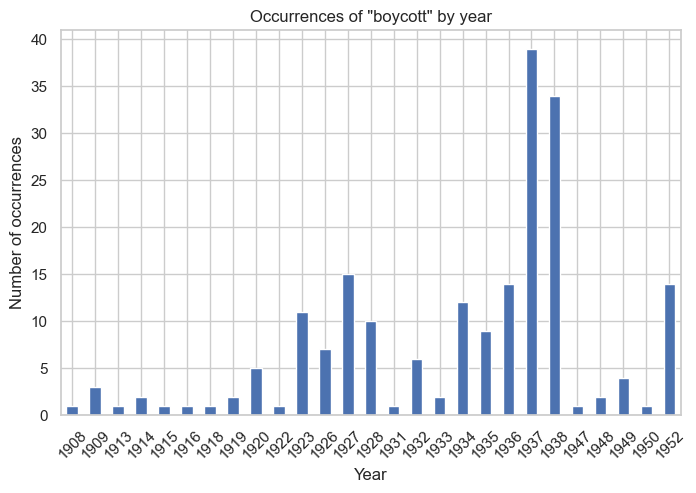

In [29]:
kwic_boycott["Year"] = kwic_boycott["Date"].dt.year

fig, ax = plt.subplots(figsize=(8, 5))
kwic_boycott["Year"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title('Occurrences of "boycott" by year')
ax.set_xlabel("Year")
ax.set_ylabel("Number of occurrences")
ax.tick_params(axis="x", labelrotation=45)
plt.show()


On peut aussi filtrer les concordances par journal ou par période, comme pour n'importe quel dataframe :

In [30]:
kwic_boycott[kwic_boycott["Source"] == "The China Press"]
kwic_boycott[(kwic_boycott["Year"] >= 1935) & (kwic_boycott["Year"] <= 1936)]


,DocId,Date,Source,left,keyword,right,Year
0,1759725800,1936-08-01,South China Morning Post Ltd.,hisa participation in an effort to nf' Ahferican,boycott,of the Games Mr Avery Brundage President of,1936
17,1425818938,1935-10-06,The China Press,Catholic weekly The Commonweal appealed' this ...,boycott,of the 1936 games Jeremiah Mahoney president5 of,1935
18,1371759994,1936-05-24,The China Press,the efforts mad In some Frenclfv quarters to,boycott,the Berlin game1 and after stressing that these,1936
19,1371753336,1936-01-05,The China Press,team abroad but the long battle for va,boycott,of the 'games by the large dissenting faction,1936
27,1371757255,1936-03-29,The China Press,France Plans,Boycott,Of Olympic Games In Berlin This Summer PARIS,1936
32,1759704302,1936-05-05,South China Morning Post Ltd.,BERLIN OLYMPICS British,Boycott,of Games Not Favoured PREPARATIONS AFOOT Londo...,1936
33,1759704302,1936-05-05,South China Morning Post Ltd.,Favoured PREPARATIONS AFOOT London Apr 22 prop...,boycott,the Olympic Games at Berlin this summer was,1936
34,1759701458,1936-05-26,South China Morning Post Ltd.,WILL NOT,BOYCOTT,Vote Against Withdrawal From Olympic Games BRI...,1936
40,1416735316,1936-10-30,The China Press,TOKYO October 29 -- Domei -- Threatening to,boycott,the Japan Amateur Athletic Federation the Toky...,1936
50,1371749765,1935-09-01,The China Press,her world Move To Disqualify Feared The Olympic,boycott,committee is ready to go on record that,1935


## 🧪 À vous de jouer — Exercice 2

1. Construisez le tableau de concordances pour le mot `"amateur"` (un enjeu central des débats olympiques de l'époque : qui a le droit de concourir ?). Combien d'occurrences trouvez-vous ?
2. Faites de même pour `"women"`. Dans quels contextes ce terme apparaît-il le plus souvent ?
3. Comparez les occurrences du mot `"China"` selon qu'elles apparaissent avant ou après 1949 (année de la fondation de la République populaire de Chine). Y a-t-il une différence dans le nombre d'occurrences par an ?
4. **Bonus** : la fonction `kwic_corpus` ne trouve que des mots exacts. Modifiez-la (ou écrivez une variante) pour qu'elle retrouve aussi les variantes d'un mot, par exemple `"Olympic"` et `"Olympics"`, à l'aide d'une expression régulière (indice : `re.match(r"olympic", tok)`).


In [ ]:
# 🧪 Essayez ici




<details>
<summary>▶️ Voir la solution</summary>

```python
# Question 1
kwic_amateur = kwic_corpus(articles, "amateur", window=8)
len(kwic_amateur)

# Question 2
kwic_women = kwic_corpus(articles, "women", window=8)
kwic_women.head(20)

# Question 3
kwic_china = kwic_corpus(articles, "China", window=6)
kwic_china["Year"] = kwic_china["Date"].dt.year
before = kwic_china[kwic_china["Year"] < 1949]
after = kwic_china[kwic_china["Year"] >= 1949]

print(len(before) / before["Year"].nunique())  # moyenne par an, avant 1949
print(len(after) / after["Year"].nunique())    # moyenne par an, après 1949

# Question 4 (bonus)
def kwic_regex(df, pattern, text_col="Text_clean", window=8):
    rows = []
    regex = re.compile(pattern, re.IGNORECASE)
    for _, row in df.iterrows():
        text = row[text_col]
        tokens = re.findall(r"[\w'-]+", text)
        for i, tok in enumerate(tokens):
            if regex.fullmatch(tok):
                left = " ".join(tokens[max(0, i - window):i])
                right = " ".join(tokens[i + 1:i + 1 + window])
                rows.append({"DocId": row["DocId"], "Date": row["Date"],
                             "left": left, "keyword": tok, "right": right})
    return pd.DataFrame(rows)

kwic_olympic_variants = kwic_regex(articles, r"olympics?")
```
</details>


# 3. N-grammes et collocations

Un **n-gramme** est une séquence de *n* mots consécutifs. Les **unigrammes** (n=1) sont des mots isolés, les **bigrammes** (n=2) des paires de mots consécutifs (ex. "Olympic Games"), les **trigrammes** (n=3) des triplets (ex. "Games of the"). L'étude des n-grammes les plus fréquents permet de repérer des **expressions figées**, des **collocations** caractéristiques d'un corpus — des informations souvent invisibles si l'on se limite à des mots isolés.

## Préparer le texte : tokenisation et mots vides (stopwords)

Avant de compter les n-grammes, on élimine généralement les **mots vides** (*stopwords* : "the", "of", "and"...), qui sont très fréquents mais peu informatifs. La bibliothèque **scikit-learn** fournit une liste de mots vides anglais prête à l'emploi :

In [31]:
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

print(list(ENGLISH_STOP_WORDS)[:15])
print(f"{len(ENGLISH_STOP_WORDS)} mots vides au total")


['nobody', 'seem', 'un', 'could', 'whither', 'afterwards', 'thru', 'every', 'herself', 'many', 'as', 'thence', 'here', 'via', 'up']
318 mots vides au total


On peut compléter cette liste avec des mots propres à notre corpus (bruit OCR récurrent, mots trop génériques dans le contexte olympique) :

In [32]:
custom_stopwords = list(ENGLISH_STOP_WORDS) + ["said", "mr", "mrs", "yesterday", "today"]


## Compter les bigrammes avec `CountVectorizer`

`CountVectorizer` (de scikit-learn) est un outil très polyvalent, conçu à la base pour le machine learning, mais très pratique pour compter des n-grammes sur un corpus entier (prend plus ou moins de temps selon a taille du corpus ) :

In [33]:
vectorizer = CountVectorizer(
    ngram_range=(2, 2),          # bigrammes uniquement
    stop_words=custom_stopwords,
    max_features=30,             # ne garder que les 30 plus fréquents
    lowercase=True,
    token_pattern=r"[a-zA-Z]{2,}"  # au moins 2 lettres, pas de chiffres/ponctuation isolée
)

dtm = vectorizer.fit_transform(articles["Text_clean"])

# Somme des occurrences de chaque bigramme sur l'ensemble du corpus
freqs = dtm.sum(axis=0)
bigrams = pd.DataFrame(
    [(word, freqs[0, idx]) for word, idx in vectorizer.vocabulary_.items()],
    columns=["bigram", "count"]
).sort_values("count", ascending=False)

bigrams


,bigram,count
0,olympic games,7765
5,united states,3857
14,new york,3028
19,far eastern,2030
20,world record,1591
1,los angeles,1591
13,track field,1411
18,years ago,1299
8,great britain,1265
24,feet inches,1260


<div class="alert alert-success" role="alert" style="background-color:#d4edda;padding:10px;border-radius:5px;">
<b>Explications</b>

- <code>ngram_range=(2, 2)</code> : ne garder que les bigrammes (mettre <code>(1, 1)</code> pour des unigrammes, <code>(3, 3)</code> pour des trigrammes, ou <code>(1, 3)</code> pour les trois à la fois).
- <code>stop_words=...</code> : élimine les mots vides <b>avant</b> de former les paires — un bigramme contenant un stopword ne sera pas retenu.
- <code>token_pattern=r"[a-zA-Z]{2,}"</code> : ne considère que les suites d'au moins 2 lettres comme des "mots", ce qui élimine une partie du bruit OCR (chiffres isolés, ponctuation mal reconnue).
- <code>vectorizer.fit_transform(...)</code> construit une <b>matrice document-terme</b> (chaque ligne = un document, chaque colonne = un n-gramme, chaque cellule = son nombre d'occurrences dans ce document). On la "somme" ensuite par colonne pour obtenir le total sur tout le corpus.
- <code>freqs = dtm.sum(axis=0)</code> additionne les occurrences de chaque bigramme dans **tous les articles du corpus**. `axis=0` signifie que l'on effectue la somme verticalement, donc colonne par colonne.
- <code>vectorizer.vocabulary_.items()</code> permet de récupérer les bigrammes identifiés par `CountVectorizer` ainsi que leur position dans la matrice.
- <code>[(word, freqs[0, idx]) for word, idx in vectorizer.vocabulary_.items()]</code> associe chaque bigramme (`word`) à son **nombre total d'occurrences** (`freqs[0, idx]`) dans le corpus.
- <code>pd.DataFrame(..., columns=["bigram", "count"])</code> transforme ces résultats en un **DataFrame pandas** contenant deux colonnes `bigram` (le bigramme) et `count` (son nombre total d'occurrences).
- Enfin, <code>.sort_values("count", ascending=False)</code> classe les bigrammes du **plus fréquent au moins fréquent**.

**En résumé :** ce code extrait les bigrammes du corpus, compte leur fréquence dans l'ensemble des articles et produit un tableau des **30 bigrammes les plus fréquents**.
</div>

Visualisons ces bigrammes :

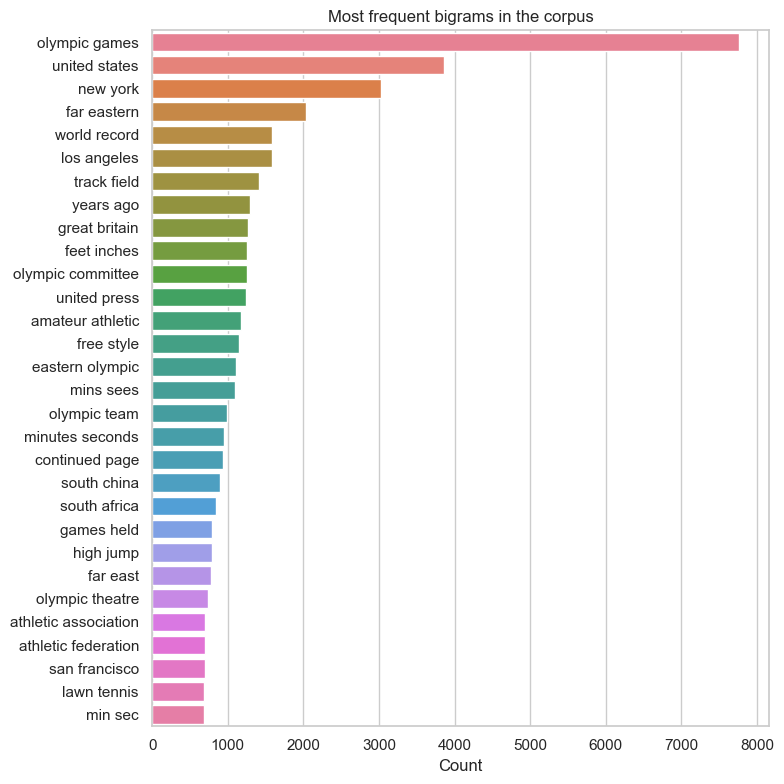

In [36]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.barplot(data=bigrams, y="bigram", x="count", hue="bigram", legend=False, ax=ax)
ax.set_title("Most frequent bigrams in the corpus")
ax.set_xlabel("Count")
ax.set_ylabel(None)
plt.tight_layout()
plt.show()


<div class="alert alert-success" role="alert" style="background-color:#d4edda;padding:10px;border-radius:5px;">
💡 Astuce : pour éliminer des bigrammes évidents comme "olympic games", utilisez le code suivant avant de construire le graphique : 

```python
bigrams_plot = bigrams[bigrams["bigram"] != "olympic games"]
```
</div> 

## Comparer le vocabulaire de deux sous-corpus

Une application classique en histoire : comparer les expressions caractéristiques de deux périodes ou de deux sources. Comparons par exemple les bigrammes des années 1930 et ceux des années 1950 :

In [42]:
def top_ngrams(texts, n=2, top_k=15, stopwords=custom_stopwords, exclude=None):
    vec = CountVectorizer(
        ngram_range=(n, n),
        stop_words=stopwords,
        max_features=top_k,
        token_pattern=r"[a-zA-Z]{2,}"
    )
    
    dtm = vec.fit_transform(texts)
    freqs = dtm.sum(axis=0)
    
    result = pd.DataFrame(
        [(w, freqs[0, i]) for w, i in vec.vocabulary_.items()],
        columns=["ngram", "count"]
    ).sort_values("count", ascending=False)

    # Optionnel : éliminer certains n-grammes prédéfinis
    if exclude:
        result = result[~result["ngram"].isin(exclude)]

    return result


bigrams_1930s = top_ngrams(articles[articles["Decade"] == 1930]["Text_clean"], n=2)
bigrams_1950s = top_ngrams(articles[articles["Decade"] == 1950]["Text_clean"], n=2)

print("--- 1930s ---")
print(bigrams_1930s)
print("--- 1950s ---")
print(bigrams_1950s)

# bigrams_to_exclude = ["olympic games", "united states"]
# bigrams_1930s = top_ngrams(articles[articles["Decade"] == 1930]["Text_clean"], n=2, exclude=bigrams_to_exclude)
# bigrams_1950s = top_ngrams(articles[articles["Decade"] == 1950]["Text_clean"], n=2, exclude=bigrams_to_exclude)




--- 1930s ---
                ngram  count
0       olympic games   4118
4       united states   1912
10           new york   1561
1         los angeles   1314
9         far eastern   1061
11       world record    987
12        feet inches    971
7         track field    883
13         free style    724
2   olympic committee    720
5       great britain    709
3        united press    682
8    amateur athletic    670
6        olympic team    642
14          years ago    639
--- 1950s ---
                ngram  count
0       olympic games    579
4       united states    263
11          mins sees    201
1   olympic committee    185
10         free style    163
2    associated press    161
5        united press    160
7       helsinki july    135
12           year old    128
9           hong kong    127
8        world record    123
6    amateur athletic    117
14        new zealand    114
13    minutes seconds     98
3      games helsinki     89


<div class="alert alert-success" role="alert" style="background-color:#d4edda;padding:10px;border-radius:5px;">

**💡 Explications :**

<code>def top_ngrams()</code> définit une fonction appelée `top_ngrams` qui permet d'identifier les **n-grammes les plus fréquents** dans un ensemble de textes. Un *n-gramme* est une séquence de *n* mots consécutifs : un bigramme contient 2 mots, un trigramme 3 mots, etc.

La fonction prend plusieurs paramètres :

* `texts` : l'ensemble des textes à analyser ;
* `n=2` : la taille des n-grammes. Par défaut, `n=2`, donc la fonction recherche des **bigrammes** ;
* `top_k=15` : nombre maximal de n-grammes à conserver ;
* `stopwords=custom_stopwords` : liste des mots vides (*stopwords*) à exclure.

<code>vec = CountVectorizer(...)</code> configure l'extraction des n-grammes :

* `ngram_range=(n, n)` : recherche uniquement des séquences de `n` mots ;
* `stop_words=stopwords` : exclut les mots présents dans la liste des *stopwords* ;
* `max_features=top_k` : conserve au maximum les `top_k` n-grammes les plus fréquents ;
* `token_pattern=r"[a-zA-Z]{2,}"` : ne conserve que les mots composés d'au moins deux lettres.

<code>dtm = vec.fit_transform(texts)</code> analyse les textes et les transforme en **Document-Term Matrix (DTM)** : les lignes correspondent aux documents, les colonnes aux n-grammes et les cellules indiquent leur nombre d'occurrences.

<code>freqs = dtm.sum(axis=0)</code> additionne les occurrences de chaque n-gramme dans **l'ensemble des textes**.

<code>[(w, freqs[0, i]) for w, i in vec.vocabulary_.items()]</code> associe ensuite chaque n-gramme (`w`) à sa **fréquence totale** dans le corpus.

<code>pd.DataFrame(...)</code> transforme les résultats en un tableau contenant deux colonnes :

* `ngram` : le n-gramme ;
* `count` : son nombre total d'occurrences.

<code>.sort_values("count", ascending=False)</code> classe enfin les résultats du **plus fréquent au moins fréquent**.

La fonction peut maintenant être réutilisée sur différentes parties du corpus. Par exemple :

<code>bigrams_1930s = top_ngrams(articles[articles["Decade"] == 1930]["Text_clean"], n=2)</code>

* `articles["Decade"] == 1930` sélectionne les articles des **années 1930** ;
* `["Text_clean"]` sélectionne uniquement leur texte nettoyé ;
* `top_ngrams(..., n=2)` calcule les bigrammes les plus fréquents dans ces articles.

La même opération est réalisée pour les années 1950 :

<code>bigrams_1950s = top_ngrams(articles[articles["Decade"] == 1950]["Text_clean"], n=2)</code>

**En résumé :** cette fonction permet d'automatiser une série d'opérations que nous avons déjà réalisées séparément : **sélectionner les n-grammes → compter leurs occurrences → conserver les plus fréquents → les classer**. Une fois définie, elle peut être réutilisée pour comparer facilement différentes parties du corpus, ici les **années 1930 et 1950**.

</div>

## Collocations statistiques (pour aller plus loin)

Compter les bigrammes les plus fréquents privilégie mécaniquement les combinaisons de mots courants. Pour repérer des associations de mots **statistiquement significatives** (même rares), on peut utiliser une mesure comme le **PMI** (*Pointwise Mutual Information*), disponible dans NLTK :

In [53]:
import nltk

nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/carmand/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [54]:
from nltk.collocations import BigramCollocationFinder, BigramAssocMeasures
from nltk.tokenize import word_tokenize

all_tokens = [t.lower() for t in word_tokenize(full_text) if t.isalpha() and t.lower() not in custom_stopwords]

finder = BigramCollocationFinder.from_words(all_tokens)
finder.apply_freq_filter(10)   # on ignore les bigrammes trop rares (moins de 10 occurrences)

pmi_bigrams = finder.nbest(BigramAssocMeasures.pmi, 20)
pmi_bigrams


[('atmos', 'phere'),
 ('philadel', 'phia'),
 ('autho', 'rities'),
 ('emer', 'gency'),
 ('roose', 'velt'),
 ('mediter', 'ranean'),
 ('approxi', 'mately'),
 ('cohens', 'kellys'),
 ('wem', 'bley'),
 ('justin', 'lynskey'),
 ('unani', 'mously'),
 ('shewan', 'tomes'),
 ('aban', 'doned'),
 ('cathe', 'dral'),
 ('exhi', 'bition'),
 ('pennsyl', 'vania'),
 ('ambas', 'sador'),
 ('chil', 'dren'),
 ('addis', 'ababa'),
 ('swit', 'zerland')]

<div class="alert alert-success" role="alert" style="background-color:#d4edda;padding:10px;border-radius:5px;">
💡 Contrairement au simple comptage de fréquences, le PMI met en avant des paires de mots qui apparaissent <b>ensemble plus souvent que ce que l'on attendrait par hasard</b>, même si elles restent rares dans l'absolu (par exemple, des noms propres composés). C'est un bon complément à l'analyse de fréquence brute.
</div>

## 🧪 À vous de jouer — Exercice 3

1. Calculez les 20 **trigrammes** les plus fréquents du corpus (`ngram_range=(3, 3)`).
2. Comparez les bigrammes du *South China Morning Post* et ceux du *China Press* (filtrez `articles` sur la colonne `Source`). Repérez-vous des différences de vocabulaire ?
3. En utilisant `top_ngrams()`, calculez les unigrammes (`n=1`) les plus fréquents des articles mentionnant le mot "war" (indice : filtrez d'abord `articles` avec `articles["Text_clean"].str.contains("war", case=False)`).


In [ ]:
# 🧪 Essayez ici




<details>
<summary>▶️ Voir la solution</summary>

```python
# Question 1
trigrams = top_ngrams(articles["Text_clean"], n=3, top_k=20)

# Question 2
bigrams_scmp = top_ngrams(articles[articles["Source"] == "South China Morning Post Ltd."]["Text_clean"], n=2)
bigrams_press = top_ngrams(articles[articles["Source"] == "The China Press"]["Text_clean"], n=2)

# Question 3
war_articles = articles[articles["Text_clean"].str.contains("war", case=False, na=False)]
top_ngrams(war_articles["Text_clean"], n=1, top_k=20)
```
</details>


# 4. Topic Modeling avec BERTopic

Le **topic modeling** (modélisation de thèmes) est une famille de méthodes visant à découvrir automatiquement les grands **thèmes** qui traversent un corpus, sans supervision préalable. La méthode historiquement la plus utilisée est le LDA (*Latent Dirichlet Allocation*) ; nous allons utiliser une approche plus récente, **BERTopic**, mieux adaptée aux textes courts et bruités car elle s'appuie sur des **embeddings** (représentations vectorielles du sens des phrases produites par un modèle de langue de type BERT), plutôt que sur le seul comptage de mots.

## Principe de BERTopic

1. Chaque document est transformé en un **vecteur numérique** (embedding) qui capture son contenu sémantique.
2. Ces vecteurs sont regroupés en **clusters** de documents similaires (via UMAP pour réduire la dimension, puis HDBSCAN pour le clustering).
3. Pour chaque cluster (= chaque *topic*), on extrait les mots les plus représentatifs (via une variante de TF-IDF appliquée au niveau des clusters, appelée c-TF-IDF).

```python
# pip install bertopic sentence-transformers
```

## Préparer les données

Le calcul des embeddings peut être lent sur un grand corpus. Pour une démonstration en séance, on va travailler sur un **échantillon** du sous-corpus rédactionnel (vous pourrez relancer l'analyse sur l'ensemble du corpus chez vous, avec plus de temps ou un GPU) :

In [55]:
!pip install bertopic sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [bertopic]3/4 [bertopic]


In [59]:
# On limite aux articles ayant un minimum de contenu (au moins 50 mots)
articles_bt = articles[articles["n_words"] >= 50].copy()

# Échantillon pour la démonstration en direct (retirez cette ligne pour tourner sur tout le corpus)
sample = articles_bt.sample(n=1500, random_state=42).reset_index(drop=True)

docs = sample["Text_clean"].tolist()
timestamps = sample["Year"].tolist()

print(f"Number of documents: {len(docs)}")


Number of documents: 1500


In [60]:
# On enlève les mots ou bigrammes trop fréquents (stopwords) pour ne pas "polluer" les topics avec des termes triviaux :

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_stopwords = {"olympic"}
stop_words = list(set(ENGLISH_STOP_WORDS).union(custom_stopwords))

# On vectorise le corpus en utilisant des n-grammes (uni- et bigrammes) et en éliminant les mots vides :

vectorizer_model = CountVectorizer(stop_words=stop_words,ngram_range=(1, 2), min_df=5)


## Entraîner un modèle BERTopic

In [ ]:
from bertopic import BERTopic

topic_model = BERTopic(vectorizer_model=vectorizer_model, verbose=True)
# topic_model = BERTopic(vectorizer_model=vectorizer_model, calculate_probabilities=True, verbose=True) # pour calculer les probabilités d'appartenance des documents aux topics
topics, probs = topic_model.fit_transform(docs)


2026-08-13 18:34:12,728 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

2026-08-13 18:34:23,484 - BERTopic - Embedding - Completed ✓
2026-08-13 18:34:23,484 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-13 18:34:24,843 - BERTopic - Dimensionality - Completed ✓
2026-08-13 18:34:24,843 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-13 18:34:24,861 - BERTopic - Cluster - Completed ✓
2026-08-13 18:34:24,863 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-13 18:34:25,321 - BERTopic - Representation - Completed ✓


## Inspecter les topics

`get_topic_info()` renvoie un résumé de tous les topics détectés, avec leur taille (nombre de documents) et leurs mots les plus représentatifs :

In [69]:
topic_model.get_topic_info()


,Topic,Count,Name,Representation,Representative_Docs
0,-1,490,-1_team_games_tho_world,"[team, games, tho, world, china, time, game, n...",[In The Limelight Of Tenth Olympic Games What ...
1,0,238,0_games_committee_international_tho,"[games, committee, international, tho, london,...",[home sports From Our Own Correspondent London...
2,1,138,1_mr_shanghai_chinese_china,"[mr, shanghai, chinese, china, tho, general, j...",[V4 jo 0 WSia CONTENTS of Vol OF The North-Chi...
3,2,137,2_record_seconds_metres_won,"[record, seconds, metres, won, time, second, f...","[San Romani Captures National 1,500-Meter Cham..."
4,3,111,3_chinese_team_china_players,"[chinese, team, china, players, football, play...",[CHINA BACKWARD IN PREPARING FOR OLYMPIC GAMES...
5,4,90,4_swimming_miss_swimmers_sees,"[swimming, miss, swimmers, sees, time, yards, ...",[HELENE MADISON BREAKS 100 METER WORLD SWIM RE...
6,5,84,5_music_mr_theatre_dance,"[music, mr, theatre, dance, programme, song, c...",[TO-DAY S BROADCAST Dance Music from Roof Gard...
7,6,43,6_boxing_fight_round_rounds,"[boxing, fight, round, rounds, ring, bout, cha...",[HOME SPORTS Our Own Correspondent SPLENDID BO...
8,7,39,7_match_england_pts_time,"[match, england, pts, time, cricket, english, ...",[HOME SPORT SCOTLAND WIN THE CALCUTTA CUP Our ...
9,8,37,8_japan_philippines_eastern_far,"[japan, philippines, eastern, far, far eastern...",[FAR EASTERN ATHLETIC ASSOCIATION DISSOLVED AS...


<div class="alert alert-success" role="alert" style="background-color:#d4edda;padding:10px;border-radius:5px;">
💡 Le topic <code>-1</code> regroupe les documents jugés trop atypiques pour être rattachés à un cluster — c'est le topic "poubelle" (<i>outliers</i>), normal et attendu avec BERTopic.
</div>

On peut examiner le détail d'un topic en particulier — ses mots-clés et leur poids :

In [63]:
topic_model.get_topic(0)


[('mr', 0.02817687165287583),
 ('shanghai', 0.026852524008559992),
 ('chinese', 0.020780395553092728),
 ('china', 0.019288000979473075),
 ('tho', 0.015155002242146862),
 ('general', 0.013871143995362085),
 ('japanese', 0.013393430146197979),
 ('government', 0.012872480930162652),
 ('mrs', 0.012486195173836721),
 ('dr', 0.012276458628193097)]

In [ ]:
# Si les fréquences on été calculées : 

probs.shape # nombre de documents x nombre de topics

array([0.01546873, 0.01748104, 0.00998632, 0.01098185, 0.01475556,
       0.0138472 , 0.01321783, 0.00999368, 0.0220049 , 0.0224294 ,
       0.01305008, 0.01397546, 0.01335401, 0.19463558, 0.03644858,
       0.04118495, 0.04468038, 0.02374693, 0.04402671, 0.02262641,
       0.02063692, 0.00889381, 0.02555054])

In [87]:
probs[0] # proportions de chaque topic pour le premier document

array([0.01546873, 0.01748104, 0.00998632, 0.01098185, 0.01475556,
       0.0138472 , 0.01321783, 0.00999368, 0.0220049 , 0.0224294 ,
       0.01305008, 0.01397546, 0.01335401, 0.19463558, 0.03644858,
       0.04118495, 0.04468038, 0.02374693, 0.04402671, 0.02262641,
       0.02063692, 0.00889381, 0.02555054])

## Visualiser les topics

BERTopic fournit plusieurs visualisations interactives intégrées (basées sur plotly) :

In [90]:
topic_model.visualize_barchart(top_n_topics=12)


In [91]:
topic_model.visualize_topics()   # carte de distance inter-topics


## Les topics au fil du temps

L'un des intérêts majeurs pour un usage historien : suivre l'**évolution des thèmes dans le temps**, grâce à `topics_over_time()` :

In [92]:
topics_over_time = topic_model.topics_over_time(docs, timestamps, nr_bins=20)

topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=10)


12it [00:00, 18.59it/s]


## Réduire le nombre de topics

BERTopic a tendance à générer beaucoup de topics, parfois redondants. On peut les fusionner automatiquement avec `reduce_topics()` :

In [93]:
topic_model.reduce_topics(docs, nr_topics=10)

topic_model.get_topic_info()


2026-08-13 18:47:57,163 - BERTopic - Topic reduction - Reducing number of topics
2026-08-13 18:47:57,174 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-13 18:47:57,657 - BERTopic - Representation - Completed ✓
2026-08-13 18:47:57,658 - BERTopic - Topic reduction - Reduced number of topics from 24 to 10


,Topic,Count,Name,Representation,Representative_Docs
0,-1,561,-1_team_mr_tho_games,"[team, mr, tho, games, chinese, china, time, w...",[Ceremony For China Olympic Athletes Held Mayo...
1,0,237,0_games_committee_tho_international,"[games, committee, tho, international, sports,...",[Votes Favoring Japan As Site Figured At 35 Co...
2,1,200,1_record_metres_seconds_time,"[record, metres, seconds, time, won, second, y...",[Four Records Fall In 2-Day Competition Parson...
3,2,110,2_theatre_mr_music_dance,"[theatre, mr, music, dance, tho, pan, programm...",[TO-DAY S BROADCAST Dance Music from Roof Gard...
4,3,101,3_team_chinese_china_games,"[team, chinese, china, games, athletic, far, j...",[CHINA OPENS WELL AT THE OLYMPIC GAMES Manila ...
5,4,95,4_shanghai_mr_chinese_china,"[shanghai, mr, chinese, china, general, japane...",[Men and Events The Rev Ronald Rees departed l...
6,5,64,5_match_tennis_england_cricket,"[match, tennis, england, cricket, time, matche...",[HOME SPORT SCOTLAND WIN THE CALCUTTA CUP Our ...
7,6,64,6_boxing_mr_won_round,"[boxing, mr, won, round, win, time, fight, wei...",[HOME SPORTS LETTER Tcani Of American Amateur ...
8,7,56,7_maru_tons_ports_20,"[maru, tons, ports, 20, dollar, jan, feb, ship...",[Due To Arrive FROM LONDON mif Aug arry Glen d...
9,8,12,8_ii_il_ol_hi,"[ii, il, ol, hi, li, ill, lie, ai, ll, lo]",[SPORTS REFLECTIONS British Sportmen Want Mora...


## Récupérer les topics dans le dataframe

Enfin, on peut réintégrer l'attribution de chaque document à son topic dans notre tableau de métadonnées, pour croiser topic et journal, topic et période, etc. :

In [94]:
sample["topic"] = topic_model.topics_

sample.groupby(["topic", "Source"]).size().unstack(fill_value=0)


Source,Peking Daily News,Peking Gazette,South China Morning Post Ltd.,The Canton Times,The China Press,The China Weekly Review,The Chinese Recorder,The Chinese Repository,The North China Herald,The Shanghai Gazette,The Shanghai Times
topic,,,,,,,,,,,
-1,1,0,251,3,213,5,0,0,53,8,27
0,0,0,144,0,71,3,0,0,16,1,2
1,0,0,112,1,67,0,0,0,15,4,1
2,0,0,28,0,27,0,0,0,12,3,40
3,0,0,40,0,48,2,0,0,10,0,1
4,0,1,29,0,15,22,1,1,13,1,12
5,0,0,39,0,17,0,0,0,7,0,1
6,0,0,35,0,19,0,0,0,6,1,3
7,0,0,23,0,23,1,0,0,7,0,2


<div class="alert alert-danger" role="alert" style="background-color:#f8d7da;padding:10px;border-radius:5px;">
⚠️ <b>Rappel méthodologique</b> : les topics produits par BERTopic (comme par tout topic model) sont des regroupements <b>statistiques</b>, pas des catégories historiques préexistantes. Ils doivent être <b>interprétés et validés</b> par un retour aux documents (via <code>topic_model.get_representative_docs(topic_id)</code>), et non pris pour argent comptant.
</div>


In [95]:
# Documents les plus représentatifs d'un topic donné, pour vérifier son interprétation
topic_model.get_representative_docs(0)


["Votes Favoring Japan As Site Figured At 35 Count La Tour Also Said To Back Nippon Finland Presents Strong Case In Supporting Olympic Claim PERFORMANCE OF ATHLETES STRESSED Island Empire Regarded As Possessing More Advantages Japan according to survey conducted by Domei can be assured of 35 votes when the International Olympic Committee meets tomorrow to decide on the venue of the 1940 Games inese wm ue wic delegations of the following tries three ballots each from Japan Germany France Italy and Great Britain two each from the United States and Canada one each from Brazil Argentina South Africa New Zealand India China Belgium Czechoslovakia Hungary and the Philippines The remaining six votes are ex pected to come from Count la Tour who holds them by proxy Under the terms of the Olympic constitution the president of the International Committee also casts the deciding vote in case of tie 1 between two countries In view of Count la Tour's speech today favoring Japan's selection as 1 the 

In [105]:
# Pour récupérer les métadonnées des documents représentatifs d'un topic, on peut filtrer le dataframe d'origine :

topic_id = 0

# Documents représentatifs identifiés par BERTopic
representative_docs = topic_model.get_representative_docs(topic_id)

# Récupération dans le dataframe d'origine
df_representative = sample[sample["Text_clean"].isin(representative_docs)][["DocId", "Title", "Date", "Source", "Text_clean"]].copy()

df_representative

,DocId,Title,Date,Source,Text_clean
616,1371774264,Olympic Games Dominate '36 Sporting News,1936-12-31,The China Press,Olympic Games Dominate '36 Sporting News Shanghai Sees Crowing Interest In Sports During Year Th...
881,1416729168,Votes Favoring Japan As Site Figured At 35,1936-08-01,The China Press,Votes Favoring Japan As Site Figured At 35 Count La Tour Also Said To Back Nippon Finland Presen...
1333,1499108239,HOME SPORTS,1914-03-24,South China Morning Post Ltd.,HOME SPORTS London March 2. ATHLETICS Matters are now moving rapidly in regard to Olympic Games ...


In [ ]:
# Pour afficher le texte complet du premier document représentatif d'un topic donné :

print(df_representative.iloc[0]["Text_clean"])

Olympic Games Dominate '36 Sporting News Shanghai Sees Crowing Interest In Sports During Year The 11th world Olympic Games held in Berlin in the first part of August were easily the outstanding sporting events of the year 1936. With more than 5,000 athletes of sexes wearing the actors of 51 nations been in two weeks of furious combat in setting that was unprecedented in the ory of the Olympiad the Berlin names surpassed anything In and Inter st luring the past twi lve months Tl 1030 of the WoMd Olympiad was not only great and athletic festival-- the most of all time-- but It was dso triumph of In s prepa aliens as ap- to U MM II ft grr 1t demonstration Nki'M accomplishment Mr than ir0 0f vi 'MfrH's rrom aiv nd ind multitudes 1l who availed -'lves or -'heap travel facilities In from oil parts of the country nto the capital iw and formed art of most impressive plr tui' -- picture or national enthusiasm unity satisfaction orderliness of purpose and all llie blg wt group of tin s Ik lu lig

In [ ]:
# Alternative : enlever ou augmenter la limite d'affichage de pandas pour voir le texte complet
# pd.set_option("display.max_colwidth", None)
# pd.set_option("display.max_colwidth", 200)

In [110]:
# Pour afficher plus de 3 articles représentatifs d'un topic donné :

topic_id = 0
n_articles = 10

# Informations BERTopic pour chaque document
doc_info = topic_model.get_document_info(docs)

# Métadonnées originales + texte
results = sample[
    ["DocId", "Title", "Date", "Source", "Text_clean"]
].reset_index(drop=True).copy()

# Ajout des résultats BERTopic
results["Topic"] = doc_info["Topic"].values
results["Topic_Name"] = doc_info["Name"].values
results["Probability"] = doc_info["Probability"].values
results["Representative"] = doc_info["Representative_document"].values

top_articles = (results[results["Topic"] == topic_id].sort_values("Probability", ascending=False).head(n_articles))

top_articles[["DocId", "Title", "Date", "Source", "Probability", "Text_clean"]]

,DocId,Title,Date,Source,Probability,Text_clean
834,1498893518,OUR ENGLISH SPORTS LETTER,1911-03-08,South China Morning Post Ltd.,1.0,OUR ENGLI SPORTS' LETTER Que Own Correspondent 1 LONDON February 3. ATHLETICS It is cle to all w...
1286,1371436822,Club Triumphs Over Time,1938-07-27,The North China Herald,1.0,Club Triumphs Over Time Shanghai July 25. By hitting glorious six and two fours In the last over...
1015,1371344789,"""No War in Japan""",1938-04-20,The North China Herald,1.0,No War in Japan New York Apr 16. Plans for the 12th Olympic Games are progressing and there is o...
375,1766499934,OLYMPIC GAMES,1948-11-23,South China Morning Post Ltd.,1.0,OLYMPIC GAMES America Would Like To See Junior Event NO BRITISH SUPPORT London Nov 21. The Unite...
1036,1766460017,PUBLIC HEALTH,1948-09-18,South China Morning Post Ltd.,1.0,PUBLIC HEALTH Olympic Exhibition in November GREAT CENTURY By Geohre Godwin One hundred years ag...
1355,1371779358,Definite Date For Olympic Gaines Is Set,1937-06-12,The China Press,1.0,Definite Date For Olympic Gaines Is Set Last Week Of August And First Of Sept In 1940 Chosen HUN...
248,1371750978,German Talks At Zuerich Are Well Received,1935-12-16,The China Press,1.0,German Talks At Zuerich Are Well Received Olympic Games In Berlin Not Only Physical But Also Int...
1062,1371763286,Baillest-Latour Tours Finland To Inspect Site,1936-07-05,The China Press,1.0,Baillest-Latour Tours Finland To Inspect Site International Olympic Head Entertained By Official...
474,1499012004,OLYMPIC ATHLETES,1913-03-05,South China Morning Post Ltd.,1.0,OLYMPIC ATHLETES DUKE OF SOMERSET S APPEAL London Mardh 3. The Duke of Somerset chair- --nian of...
260,1768703626,HOME SPORTS LETTER,1952-11-04,South China Morning Post Ltd.,1.0,HOME SPOETS LETTER ISetafolishing Control Boards For Profes^ioiiid Konng Lvi g' FOOTB ALUS GLAMO...


<div class="alert alert-danger" role="alert" style="background-color:#f8d7da;padding:10px;border-radius:5px;">
⚠️ <b>Attention à l'interprétation</b> : ce ne sont pas nécessairement les documents marqués <code>Representative_document=True</code> par BERTopic. Ce sont les documents du topic ayant les probabilités d'appartenance les plus élevées. 
</div>

## 🧪 À vous de jouer — Exercice 4

1. Combien de topics le modèle a-t-il détecté avant réduction (voir `get_topic_info()` avant l'appel à `reduce_topics()`) ?
2. Identifiez un topic qui semble lié à la **politique internationale** (mots comme "war", "government", "japan"...). Notez son numéro et ses mots-clés.
3. Utilisez `get_representative_docs()` sur ce topic pour lire 2-3 documents représentatifs : le thème vous semble-t-il cohérent ?
4. **Bonus** : relancez l'entraînement sur un sous-corpus filtré (par exemple, uniquement les articles d'un seul journal, ou d'une seule décennie). Les topics obtenus sont-ils différents ?


In [ ]:
# 🧪 Essayez ici




<details>
<summary>▶️ Voir une piste de solution</summary>

```python
# Question 1 : regarder le nombre de lignes de topic_model.get_topic_info() (hors ligne -1)
# avant d'appeler reduce_topics()

# Question 2-3
topic_model.get_topic(3)              # remplacer 3 par le numéro repéré
topic_model.get_representative_docs(3)

# Question 4 (bonus)
subset_docs = sample[sample["Source"] == "South China Morning Post Ltd."]["Text_clean"].tolist()
topic_model_subset = BERTopic(language="english")
topics_subset, _ = topic_model_subset.fit_transform(subset_docs)
topic_model_subset.get_topic_info().head(10)
```
</details>


# 5. Reconnaissance d'entités nommées (NER)

La **reconnaissance d'entités nommées** (*Named Entity Recognition*, NER) consiste à repérer automatiquement, dans un texte, les mentions de **personnes** (PERSON), **lieux** (GPE/LOC), **organisations** (ORG), **dates**, etc. C'est un outil précieux pour un usage historien : reconstituer les réseaux d'acteurs, cartographier les lieux mentionnés, suivre l'apparition/disparition d'une entité dans le temps.

Nous utilisons **spaCy**, l'une des bibliothèques de référence en traitement automatique des langues.

```python
# pip install spacy
# python -m spacy download en_core_web_sm
```


In [112]:
!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 22.2 MB/s eta 0:00:00 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [113]:
import spacy

nlp = spacy.load("en_core_web_sm")


## Un premier exemple

Testons sur un seul document :

In [114]:
doc = nlp(articles["Text_clean"].iloc[0])

for ent in doc.ents[:20]:
    print(ent.text, "->", ent.label_)


OLYMPIC -> WORK_OF_ART
Los Angeles Event -> ORG
Los Angeles -> GPE
the World Olympic Games -> EVENT
1932 -> DATE
Saturday July 30 -> DATE
August 14 -> DATE
the Organizing Committee -> ORG
Olympic -> DATE
Congress -> ORG
Berlin -> GPE
16 days -> DATE
135 -> CARDINAL
equestrian -> NORP
Modern Pentathlon -> ORG
50 metres -> QUANTITY
Olympic -> FAC
Berlin -> GPE
the Inter national Olympic Committee the Organizing Committee -> ORG
the Games of the Tenth Olympiad -> EVENT


On peut visualiser ces entités directement dans le notebook grâce à **displacy** :

In [115]:
from spacy import displacy

displacy.render(doc[:400], style="ent", jupyter=True)   # les 400 premiers tokens, pour la lisibilité


<div class="alert alert-success" role="alert" style="background-color:#d4edda;padding:10px;border-radius:5px;">
<b>Principaux types d'entités (modèle anglais)</b>

| Label | Signification |
|---|---|
| `PERSON` | Personne |
| `GPE` | Entité géopolitique (pays, ville, région) |
| `LOC` | Lieu non-politique (montagne, mer...) |
| `ORG` | Organisation, institution, entreprise |
| `DATE` | Date ou période |
| `EVENT` | Événement nommé (ex. "the Olympic Games") |
| `NORP` | Nationalité, groupe religieux ou politique |
</div>

## Appliquer la NER à l'échelle du corpus

Pour traiter efficacement de nombreux documents, spaCy propose `nlp.pipe()`, plus rapide qu'une boucle appelant `nlp()` document par document. Comme pour BERTopic, on travaille sur un échantillon pour la démonstration :

In [118]:
sample_ner = articles[articles["n_words"] >= 50].sample(n=50, random_state=42).reset_index(drop=True)

rows = []
for doc_id, date, source, doc in zip(
    sample_ner["DocId"], sample_ner["Date"], sample_ner["Source"],
    nlp.pipe(sample_ner["Text_clean"], batch_size=50, disable=["lemmatizer"])
):
    for ent in doc.ents:
        rows.append({
            "DocId": doc_id, "Date": date, "Source": source,
            "entity": ent.text, "label": ent.label_
        })

entities = pd.DataFrame(rows)
entities.head(10)


,DocId,Date,Source,entity,label
0,1416528638,1935-07-13,The China Press,Load Tennis Stars To Clash With Men From North,PERSON
1,1416528638,1935-07-13,The China Press,two,CARDINAL
2,1416528638,1935-07-13,The China Press,Trcm Norllti,PERSON
3,1416528638,1935-07-13,The China Press,China,GPE
4,1416528638,1935-07-13,The China Press,JUiail -1,PERSON
5,1416528638,1935-07-13,The China Press,1,CARDINAL
6,1416528638,1935-07-13,The China Press,Japanese,NORP
7,1416528638,1935-07-13,The China Press,Lo,PERSON
8,1416528638,1935-07-13,The China Press,0ic;cb?3,CARDINAL
9,1416528638,1935-07-13,The China Press,Luni,PERSON


<div class="alert alert-success" role="alert" style="background-color:#d4edda;padding:10px;border-radius:5px;">
💡 <code>disable=["lemmatizer"]</code> désactive les composants du pipeline spaCy dont on n'a pas besoin (ici, la lemmatisation), ce qui accélère nettement le traitement — un réflexe utile sur de gros corpus.
</div>

## Les entités les plus fréquentes

Quels lieux (`GPE`) sont les plus souvent mentionnés ?

In [119]:
entities[entities["label"] == "GPE"]["entity"].value_counts().head(20)


entity
Shanghai             32
China                26
Japan                25
England              19
Hongkong             18
Canton               12
America              11
Canada               11
Australia             9
Scotland              8
Hamburg               8
France                7
Manila                7
London                6
Britain               5
South Africa          5
Germany               5
Indiana               5
the United States     5
Los Angeles           4
Name: count, dtype: int64

Quelles personnes (`PERSON`) ?

In [120]:
entities[entities["label"] == "PERSON"]["entity"].value_counts().head(20)


entity
Tsoy          8
Arthur        7
Eastman       7
John          7
Carson        6
Smith         6
Chang         4
Colony        4
Chen          4
Ting          4
ho            4
Tientsin      4
Baer          3
Perry         3
Gallopers     3
Templeton     3
Lhe           3
Brundage      3
Lee           3
Fred Perry    3
Name: count, dtype: int64

<div class="alert alert-danger" role="alert" style="background-color:#f8d7da;padding:10px;border-radius:5px;">
⚠️ <b>Limites à garder à l'esprit</b> : le modèle spaCy utilisé (<code>en_core_web_sm</code>) a été entraîné sur de l'anglais contemporain. Sur un texte historique et bruité par l'OCR, il commettra davantage d'erreurs : entités mal découpées, noms propres non reconnus, orthographes anciennes non prises en charge. La NER doit être considérée comme un outil de <b>repérage rapide à valider</b>, pas comme une vérité absolue — d'où l'intérêt de toujours pouvoir revenir au KWIC (section 2) pour vérifier un résultat dans son contexte.
</div>

Visualisons les 15 organisations (`ORG`) les plus citées :

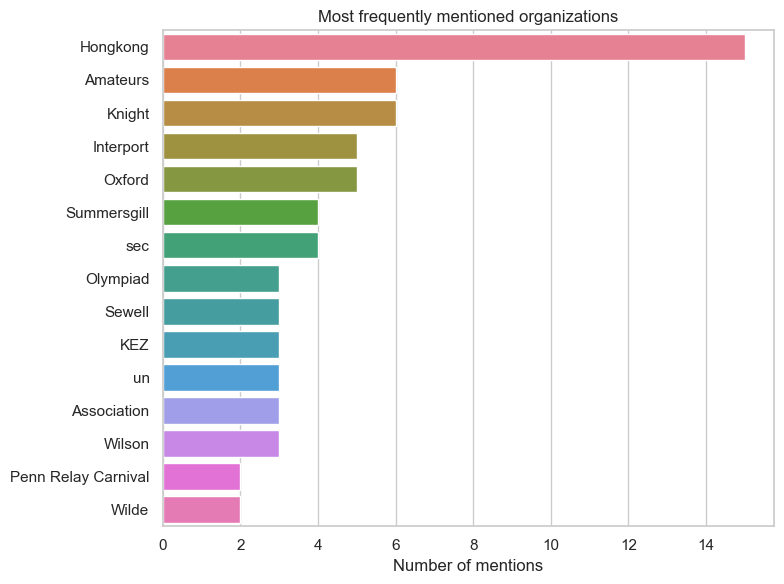

In [121]:
top_orgs = entities[entities["label"] == "ORG"]["entity"].value_counts().head(15).reset_index()
top_orgs.columns = ["entity", "n"]

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=top_orgs, y="entity", x="n", hue="entity", legend=False, ax=ax)
ax.set_title("Most frequently mentioned organizations")
ax.set_xlabel("Number of mentions")
ax.set_ylabel(None)
plt.tight_layout()
plt.show()


## Les entités au fil du temps

Suivons l'évolution des mentions de "Japan" au fil des années — un sujet chargé d'histoire dans le contexte des Jeux Olympiques et des relations sino-japonaises :

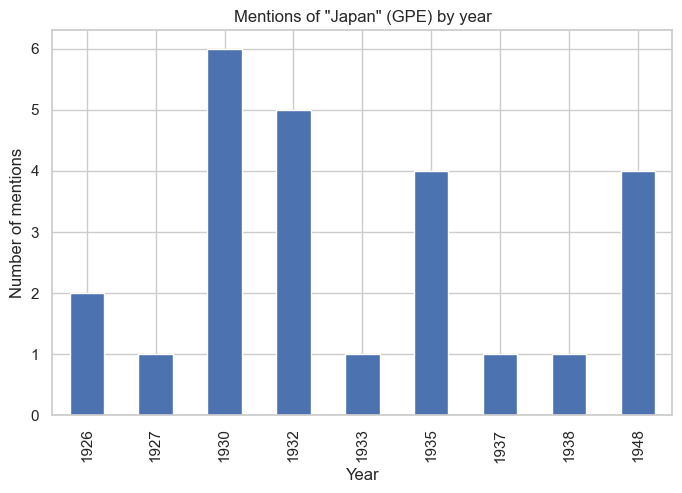

In [122]:
entities["Year"] = pd.to_datetime(entities["Date"]).dt.year

japan_mentions = entities[(entities["entity"] == "Japan") & (entities["label"] == "GPE")]

fig, ax = plt.subplots(figsize=(8, 5))
japan_mentions["Year"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title('Mentions of "Japan" (GPE) by year')
ax.set_xlabel("Year")
ax.set_ylabel("Number of mentions")
plt.show()


## 🧪 À vous de jouer — Exercice 5

1. Quelles sont les 10 dates (`DATE`) les plus fréquemment mentionnées dans le corpus ?
2. Combien de personnes (`PERSON`) **différentes** (uniques) ont été identifiées dans l'échantillon ?
3. Choisissez un lieu (`GPE`) qui vous intéresse dans le top 20 et tracez sa fréquence de mentions par année, comme pour "Japan" ci-dessus.
4. **Bonus** : à l'aide de la fonction `kwic_corpus` de la section 2, vérifiez dans leur contexte 3 mentions d'une personne de votre choix parmi les plus citées. L'entité vous semble-t-elle correctement identifiée par spaCy ?


In [ ]:
# 🧪 Essayez ici




<details>
<summary>▶️ Voir la solution</summary>

```python
# Question 1
entities[entities["label"] == "DATE"]["entity"].value_counts().head(10)

# Question 2
entities[entities["label"] == "PERSON"]["entity"].nunique()

# Question 3 (exemple avec "China")
china_mentions = entities[(entities["entity"] == "China") & (entities["label"] == "GPE")]
fig, ax = plt.subplots(figsize=(8, 5))
china_mentions["Year"].value_counts().sort_index().plot(kind="bar", ax=ax)
plt.show()

# Question 4 (exemple)
kwic_corpus(articles, "Owens", window=10)   # ex. Jesse Owens, athlète des JO de 1936
```
</details>


# 6. Analyse de sentiment *(bonus)*

L'**analyse de sentiment** vise à estimer automatiquement la tonalité (positive, négative, neutre) d'un texte. Nous utilisons ici **VADER** (*Valence Aware Dictionary and sEntiment Reasoner*), un outil simple, rapide et fondé sur un **lexique** (une liste de mots associés à un score de polarité), disponible via NLTK.

```python
# nltk.download("vader_lexicon")
```

<div class="alert alert-danger" role="alert" style="background-color:#f8d7da;padding:10px;border-radius:5px;">
⚠️ <b>Limites importantes</b> : VADER a été conçu à l'origine pour des textes contemporains courts (réseaux sociaux). Appliqué à de la presse historique en anglais, ses résultats doivent être interprétés avec <b>beaucoup de prudence</b> : le lexique ne connaît pas les tournures d'époque, et le sens d'un mot peut avoir changé. Considérez ces scores comme un indice exploratoire à confirmer par une lecture qualitative, jamais comme une mesure définitive de la tonalité d'un article.
</div>


In [123]:
import nltk
nltk.download("vader_lexicon", quiet=True)

from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

# Exemple sur une phrase
sia.polarity_scores("China achieved a magnificent victory at the Olympic Games.")


{'neg': 0.0, 'neu': 0.642, 'pos': 0.358, 'compound': 0.5994}

<div class="alert alert-success" role="alert" style="background-color:#d4edda;padding:10px;border-radius:5px;">
💡 <code>polarity_scores()</code> renvoie quatre valeurs : <code>neg</code>, <code>neu</code>, <code>pos</code> (proportions du texte jugées négatives / neutres / positives) et <code>compound</code>, un score global normalisé entre -1 (très négatif) et +1 (très positif) — c'est généralement cette dernière valeur que l'on utilisera pour comparer des documents entre eux.
</div>

## Appliquer VADER à l'échelle du corpus

Comme VADER est fondé sur un lexique (donc rapide, pas de modèle de deep learning), on peut l'appliquer à l'ensemble du sous-corpus rédactionnel sans avoir besoin d'échantillonner :

In [124]:
articles["sentiment"] = articles["Text_clean"].apply(lambda t: sia.polarity_scores(t)["compound"])

articles[["Title", "Source", "Year", "sentiment"]].sort_values("sentiment", ascending=False).head(10)


,Title,Source,Year,sentiment
16936,PRIZE DISTRIBUTIONS,South China Morning Post Ltd.,1922,1.0
16925,China's Davis Cup Pioneers' Voyage To The United States In 1928 Is Recalled In Detail,The China Press,1929,1.0
16801,THE RACES,South China Morning Post Ltd.,1919,1.0
16958,DESCRIPTION OF THE CITY OF CANTON,The Chinese Repository,1833,1.0
3468,Japan's Athletic Forces Preparing To invade U.S. For Olympiad,The China Press,1932,1.0
16916,THE RACES,South China Morning Post Ltd.,1919,1.0
16946,LONDON,The North China Herald,1906,1.0
16918,INTERNATIONAL RECREATION CLUB,The North China Herald,1913,1.0
16955,THE FIRST ANNUAL MEETING OF THE CHINESE TRACT SOCIETY,The North China Herald,1879,1.0
16943,WHERE TO TAKE A SUMMER HOLIDAY,The North China Herald,1897,1.0


<div class="alert alert-success" role="alert" style="background-color:#d4edda;padding:10px;border-radius:5px;">
💡 Sur des articles longs, VADER agrège le score de chaque phrase — un article globalement factuel mais contenant un paragraphe très négatif (par exemple, sur un conflit) peut obtenir un score contrasté. Pour une analyse plus fine, on peut aussi calculer un score <b>par phrase</b> avec <code>nltk.sent_tokenize()</code> plutôt que par article entier.
</div>

## Distribution des scores de sentiment

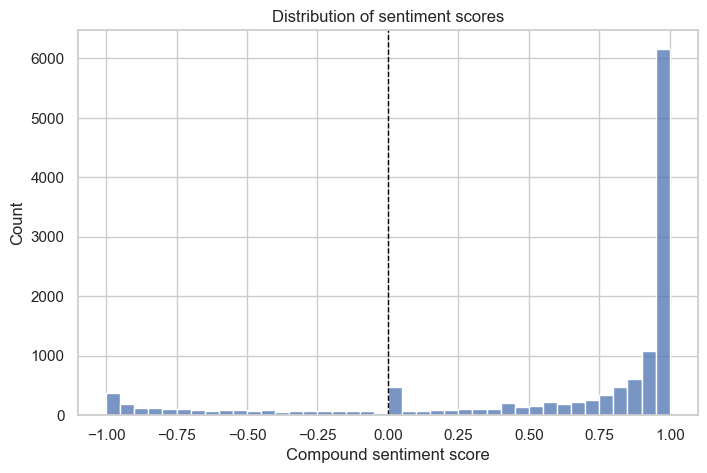

In [125]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=articles, x="sentiment", bins=40, ax=ax)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Distribution of sentiment scores")
ax.set_xlabel("Compound sentiment score")
plt.show()


## Évolution du sentiment dans le temps

Le sentiment moyen des articles évolue-t-il au fil du temps — par exemple, autour des grandes crises politiques des années 1930-1940 ?

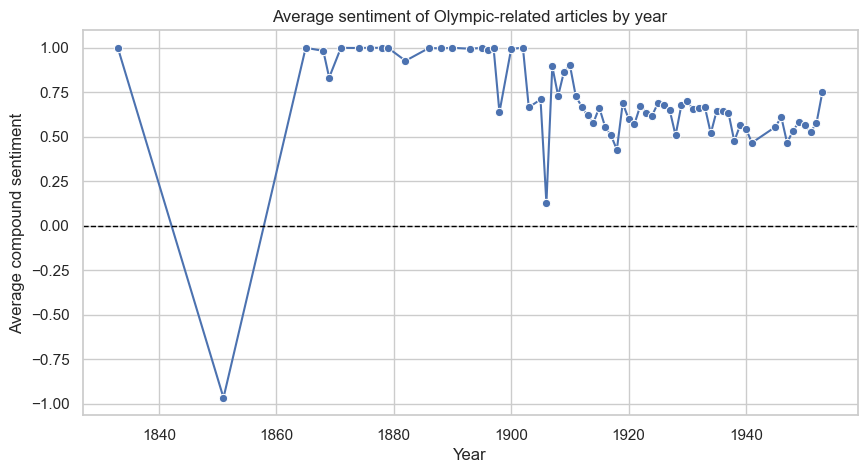

In [126]:
sentiment_by_year = articles.groupby("Year")["sentiment"].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=sentiment_by_year, x="Year", y="sentiment", marker="o", ax=ax)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Average sentiment of Olympic-related articles by year")
ax.set_ylabel("Average compound sentiment")
plt.show()


## Comparer le sentiment selon un mot-clé

On peut combiner sentiment et KWIC (section 2) : par exemple, comparer le sentiment moyen des articles mentionnant "victory" à ceux mentionnant "boycott" :

In [ ]:
victory_articles = articles[articles["Text_clean"].str.contains("victory", case=False, na=False)]
boycott_articles = articles[articles["Text_clean"].str.contains("boycott", case=False, na=False)]

print("Sentiment moyen ('victory') :", victory_articles["sentiment"].mean())
print("Sentiment moyen ('boycott') :", boycott_articles["sentiment"].mean())


Sentiment moyen ('victory') : 0.8474831254103744
Sentiment moyen ('boycott') : 0.21326870229007636


## 🧪 À vous de jouer — Exercice 6

1. Quels sont les 5 articles au sentiment le plus **négatif** du corpus ? Lisez le titre et les 200 premiers caractères de chacun : le score vous semble-t-il justifié ?
2. Comparez le sentiment moyen des articles du *South China Morning Post* à celui du *China Press*.
3. **Bonus** : comparez le sentiment moyen des articles publiés lors des années olympiques (1932, 1936, 1948, 1952) à celui des autres années.


In [ ]:
# 🧪 Essayez ici




<details>
<summary>▶️ Voir la solution</summary>

```python
# Question 1
most_negative = articles.sort_values("sentiment").head(5)
for _, row in most_negative.iterrows():
    print(row["Title"], "-", row["sentiment"])
    print(row["Text_clean"][:200])
    print("---")

# Question 2
articles.groupby("Source")["sentiment"].mean().sort_values(ascending=False)

# Question 3
olympic_years = [1932, 1936, 1948, 1952]
articles["is_olympic_year"] = articles["Year"].isin(olympic_years)
articles.groupby("is_olympic_year")["sentiment"].mean()
```
</details>


# 7. Mini-projet de synthèse

Il est temps de combiner l'ensemble des méthodes vues aujourd'hui sur une **petite investigation en autonomie** (30-40 min). Travaillez seul·e ou en binôme.

## 🧪 Consignes

Choisissez **un sujet d'enquête** parmi ces trois propositions (ou proposez le vôtre, en lien avec votre propre recherche) :

- **A. Les Jeux de Berlin (1936) et la question du boycott.**
- **B. La représentation des athlètes chinois dans la presse.**
- **C. Le lien entre Jeux Olympiques et tensions internationales (Japon, guerre...).**

Pour le sujet choisi, produisez une mini-analyse combinant **au moins 4 des 6 méthodes vues aujourd'hui** :

1. **Exploration** : construisez un sous-corpus pertinent (filtrage par mot-clé, période, journal...) et décrivez-le (nombre d'articles, répartition temporelle, répartition par journal).
2. **KWIC** : choisissez 2-3 mots-clés propres à votre sujet et examinez leurs occurrences en contexte.
3. **N-grammes** : quelles sont les expressions les plus caractéristiques de ce sous-corpus ?
4. **NER** : quelles personnes/lieux/organisations reviennent le plus souvent ?
5. **BERTopic** (si le sous-corpus est assez volumineux, > 200 documents) : quels sous-thèmes se dégagent ?
6. **Sentiment** : la tonalité évolue-t-elle au fil du temps ou selon le journal ?

Concluez par quelques lignes de synthèse : qu'apprenez-vous sur votre sujet grâce à cette approche quantitative, que la seule lecture de quelques articles n'aurait pas permis de voir aussi vite ?


In [ ]:
# 🧪 Votre code ici — utilisez autant de cellules que nécessaire





<details>
<summary>▶️ Voir un exemple de démarche (sujet A : le boycott des Jeux de Berlin)</summary>

```python
# 1. Exploration : sous-corpus centré sur 1935-1936
berlin = articles[(articles["Year"] >= 1935) & (articles["Year"] <= 1936)]
berlin["Source"].value_counts()
berlin["Year"].value_counts()

# 2. KWIC
kwic_boycott_berlin = kwic_corpus(berlin, "boycott", window=10)
kwic_nazi = kwic_corpus(berlin, "Nazi", window=10)

# 3. N-grammes
top_ngrams(berlin["Text_clean"], n=2, top_k=20)

# 4. NER
doc_ents = []
for doc in nlp.pipe(berlin["Text_clean"], batch_size=50):
    doc_ents.extend([(ent.text, ent.label_) for ent in doc.ents])
pd.DataFrame(doc_ents, columns=["entity", "label"]).query("label == 'GPE'")["entity"].value_counts().head(10)

# 5. BERTopic (si assez de documents)
# topic_model_berlin = BERTopic(language="english")
# topics, _ = topic_model_berlin.fit_transform(berlin["Text_clean"].tolist())
# topic_model_berlin.get_topic_info()

# 6. Sentiment
berlin["sentiment"] = berlin["Text_clean"].apply(lambda t: sia.polarity_scores(t)["compound"])
berlin.groupby("Source")["sentiment"].mean()
```
</details>


# Aide-mémoire

## Glossaire de la fouille de texte

| Terme | Description |
|---|---|
| **Corpus** | Ensemble structuré de documents textuels rassemblés pour être étudiés collectivement. |
| **Token / Tokenisation** | Unité minimale de découpage d'un texte (mot, ponctuation) ; la tokenisation est l'opération qui produit ces unités. |
| **Stopword (mot vide)** | Mot très fréquent mais peu porteur de sens (« the », « of »...), souvent exclu des analyses fréquentielles. |
| **N-gramme** | Séquence de *n* tokens consécutifs (bigramme = 2, trigramme = 3...). |
| **Collocation** | Association de mots qui apparaissent ensemble plus souvent que ne le voudrait le hasard. |
| **KWIC (concordance)** | Affichage d'un mot-clé entouré de son contexte immédiat, pour toutes ses occurrences dans un corpus. |
| **Embedding** | Représentation numérique (vecteur) d'un mot, d'une phrase ou d'un document, censée capturer son sens. |
| **Topic modeling** | Famille de méthodes visant à détecter automatiquement les grands thèmes (*topics*) d'un corpus. |
| **NER (reconnaissance d'entités nommées)** | Extraction automatique des mentions de personnes, lieux, organisations, dates, etc. |
| **Lemme / Lemmatisation** | Forme canonique (« dictionnaire ») d'un mot (ex. « was » → « be ») ; la lemmatisation regroupe les variantes flexionnelles d'un même mot. |
| **Analyse de sentiment** | Estimation automatique de la tonalité (positive/négative/neutre) d'un texte. |
| **OCR (reconnaissance optique de caractères)** | Procédé de transcription automatique d'un texte à partir d'un scan/image, source fréquente de « bruit » dans les corpus historiques numérisés. |
| **Lexique (dictionnaire de sentiment)** | Liste de mots associés à un score de polarité, utilisée par les méthodes d'analyse de sentiment fondées sur des règles (comme VADER). |

## Index des fonctions

| Fonction | Bibliothèque | Rôle |
|---|---|---|
| `pd.to_datetime()` | pandas | Convertit une colonne en dates |
| `re.sub()` / `re.findall()` | re (natif) | Recherche/remplacement par expression régulière |
| `word_tokenize()` | nltk | Découpe un texte en tokens |
| `nltk.Text().concordance()` | nltk | Affiche les concordances (KWIC) d'un mot |
| `CountVectorizer(ngram_range=...)` | scikit-learn | Compte les n-grammes d'un corpus |
| `ENGLISH_STOP_WORDS` | scikit-learn | Liste de mots vides anglais |
| `BigramCollocationFinder` | nltk | Détecte les collocations statistiques (PMI...) |
| `BERTopic()` | bertopic | Modélisation de sujets par embeddings + clustering |
| `.fit_transform()` | bertopic | Entraîne le modèle et attribue un topic à chaque document |
| `.get_topic_info()` / `.get_topic()` | bertopic | Inspecte les topics détectés |
| `.visualize_barchart()` / `.visualize_topics()` | bertopic | Visualisations interactives des topics |
| `.topics_over_time()` | bertopic | Suit l'évolution des topics dans le temps |
| `spacy.load()` | spaCy | Charge un modèle de langue |
| `nlp()` / `nlp.pipe()` | spaCy | Applique le pipeline NLP à un (ou plusieurs) texte(s) |
| `doc.ents` | spaCy | Liste des entités nommées détectées dans un document |
| `displacy.render()` | spaCy | Visualise les entités nommées dans le texte |
| `SentimentIntensityAnalyzer().polarity_scores()` | nltk (VADER) | Calcule un score de sentiment |

## Où trouver de l'aide ?

1. **Documentation officielle** : [pandas](https://pandas.pydata.org/docs/), [NLTK](https://www.nltk.org/), [scikit-learn](https://scikit-learn.org/stable/), [spaCy](https://spacy.io/usage), [BERTopic](https://maartengr.github.io/BERTopic/).
2. **Le manuel NLTK en ligne** : *Natural Language Processing with Python* ([nltk.org/book](https://www.nltk.org/book/)), en accès libre, avec de nombreux exemples pratiques.
3. **The Programming Historian** : des tutoriels pensés pour les SHS sur la NER, le topic modeling, l'analyse de corpus ([programminghistorian.org](https://programminghistorian.org/)).
4. **HistText** : pour toute question sur la constitution du corpus source (ProQuest Chinese Newspapers) et les fonctionnalités de recherche/export de la plateforme.
5. **Stack Overflow, ChatGPT, Claude** : comme pour tout code Python — donnez le maximum de contexte (message d'erreur complet, exemple de données, bibliothèque utilisée) pour obtenir une réponse pertinente.

<div class="alert alert-success" role="alert" style="background-color:#d4edda;padding:10px;border-radius:5px;">
💡 <b>Pour prolonger cette séance</b> : toutes les méthodes vues aujourd'hui peuvent être combinées avec ce que vous avez appris en Séance 1 (manipulation de dataframes, visualisation) pour construire des analyses de plus en plus fines. Le meilleur point de départ pour vos propres corpus est souvent de recommencer par la section 1 (exploration des métadonnées) — c'est elle qui révèle le plus souvent les biais et les limites d'un corpus avant toute analyse plus poussée.
</div>
